In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [6]:
filepath = 'boston_cleaned_data.csv'
df = pd.read_csv(filepath)
date_cols = [col for col in df.columns if col.count('-') == 2]
metadata_cols = [col for col in df.columns if col not in date_cols]

In [13]:
def reshape_to_long(df, date_cols, metadata_cols):
    zori_long = df[metadata_cols + date_cols].melt(
        id_vars=metadata_cols,
        value_vars=date_cols,
        var_name='Date',
        value_name='ZORI'
    )
    
    zori_long['Date'] = pd.to_datetime(zori_long['Date'])
    zori_long['ZORI'] = pd.to_numeric(zori_long['ZORI'], errors='coerce')
    zori_long = zori_long.sort_values(['ZipCode', 'Date']).reset_index(drop=True)
    
    return zori_long

def date_subtract_year(date_obj):
    try:
        return pd.Timestamp(year=date_obj.year-1, month=date_obj.month, day=date_obj.day)
    except ValueError:
        return pd.Timestamp(year=date_obj.year-1, month=date_obj.month, day=28)


In [36]:
zori_long = reshape_to_long(df, date_cols, metadata_cols)
valid_prices = zori_long['ZORI'].dropna()
print(f"Count: {len(valid_prices)}")
print(f"Mean: ${valid_prices.mean():.2f}")
print(f"Median: ${valid_prices.median():.2f}")
print(f"Std Dev: ${valid_prices.std():.2f}")
print(f"Min: ${valid_prices.min():.2f}")
print(f"Max: ${valid_prices.max():.2f}")

Count: 4256
Mean: $2700.47
Median: $2619.38
Std Dev: $585.38
Min: $1592.77
Max: $5691.15


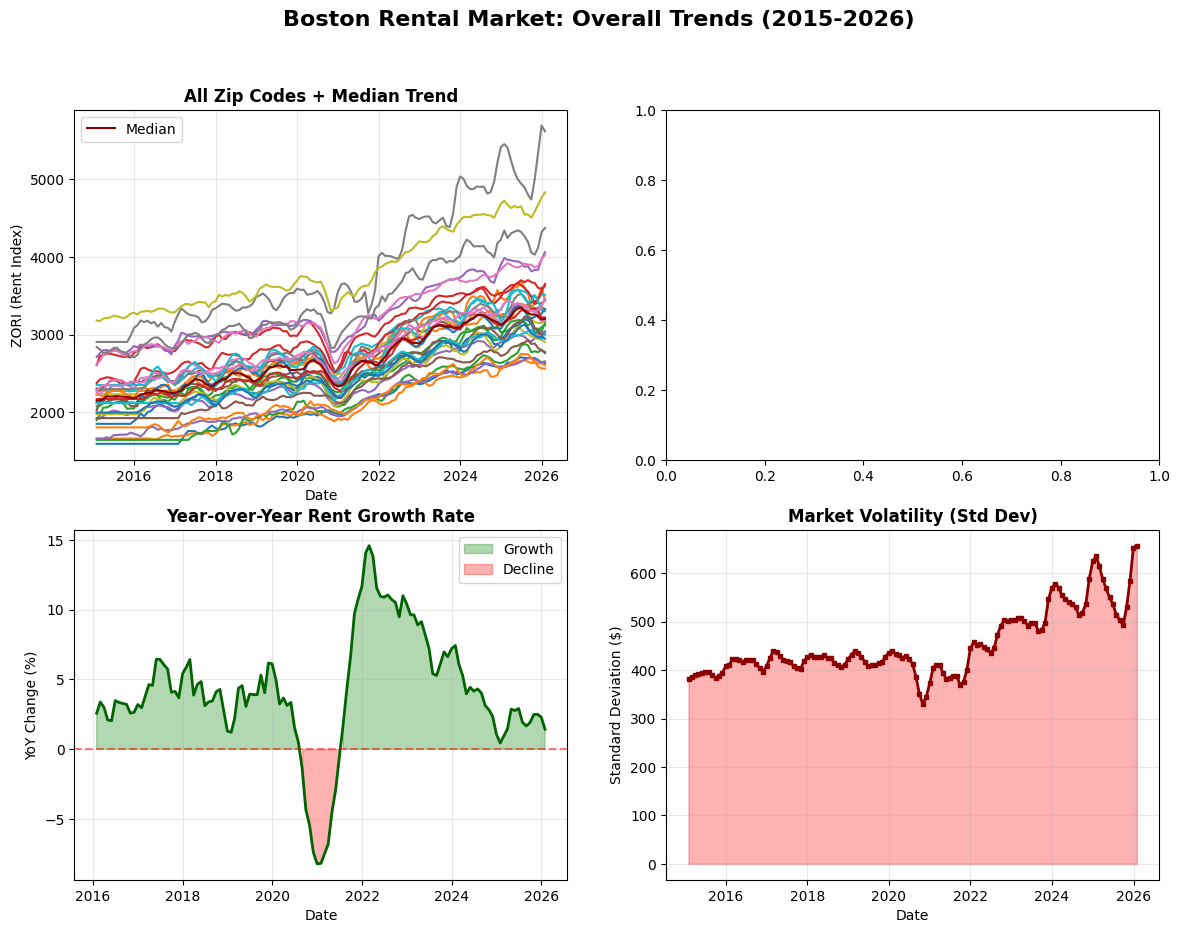

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Boston Rental Market: Overall Trends (2015-2026)', fontsize=16, fontweight='bold')
ax = axes[0, 0]
for zip_code in zori_long['ZipCode'].unique():
    zip_data = zori_long[zori_long['ZipCode'] == zip_code].sort_values('Date')
    ax.plot(zip_data['Date'], zip_data['ZORI'])
    
monthly_median = zori_long.groupby('Date')['ZORI'].median()
ax.plot(monthly_median.index, monthly_median.values, color='darkred', label='Median')
ax.set_title('All Zip Codes + Median Trend', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('ZORI (Rent Index)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
yoy_change = []
dates = []
for date in zori_long['Date'].unique():
    date_12m_ago = date_subtract_year(date)
        
    current_prices = zori_long[zori_long['Date'] == date]['ZORI']
    past_prices = zori_long[zori_long['Date'] == date_12m_ago]['ZORI']
        
    if len(current_prices) > 0 and len(past_prices) > 0:
        yoy = ((current_prices.median() - past_prices.median()) / past_prices.median() * 100)
        yoy_change.append(yoy)
        dates.append(date)
    
ax.plot(dates, yoy_change, color='darkgreen', linewidth=2)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.fill_between(dates, 0, yoy_change, where=(np.array(yoy_change) >= 0), alpha=0.3, color='green', label='Growth')
ax.fill_between(dates, 0, yoy_change, where=(np.array(yoy_change) < 0), alpha=0.3, color='red', label='Decline')
    
ax.set_title('Year-over-Year Rent Growth Rate', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('YoY Change (%)')
ax.legend()
ax.grid(True, alpha=0.3)
    
ax = axes[1, 1]
monthly_std = zori_long.groupby('Date')['ZORI'].std()
ax.plot(monthly_std.index, monthly_std.values, color='darkred', linewidth=2, marker='s', markersize=3)
ax.fill_between(monthly_std.index, monthly_std.values, alpha=0.3, color='red')
ax.set_title('Market Volatility (Std Dev)', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Standard Deviation ($)')
ax.grid(True, alpha=0.3)


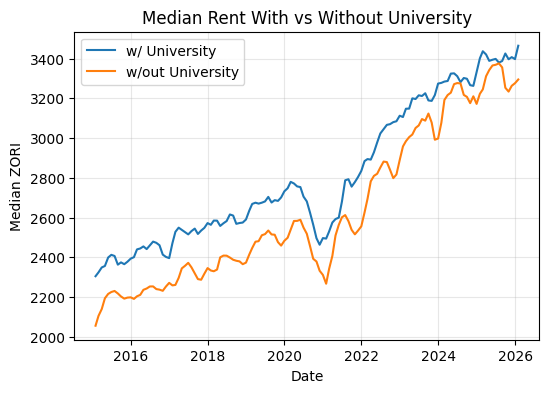

In [35]:
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)
with_uni = zori_long[zori_long['HasUniversity'] == True]
without_uni = zori_long[zori_long['HasUniversity'] == False]

monthly_with_uni = with_uni.groupby('Date')['ZORI'].median()
monthly_without_uni = without_uni.groupby('Date')['ZORI'].median()
ax.plot(monthly_with_uni.index, monthly_with_uni.values, label='w/ University')
ax.plot(monthly_without_uni.index, monthly_without_uni.values,label='w/out University')
    
ax.set_title('Median Rent With vs Without University')
ax.set_xlabel('Date')
ax.set_ylabel('Median ZORI')
ax.legend()
ax.grid(True, alpha=0.3)

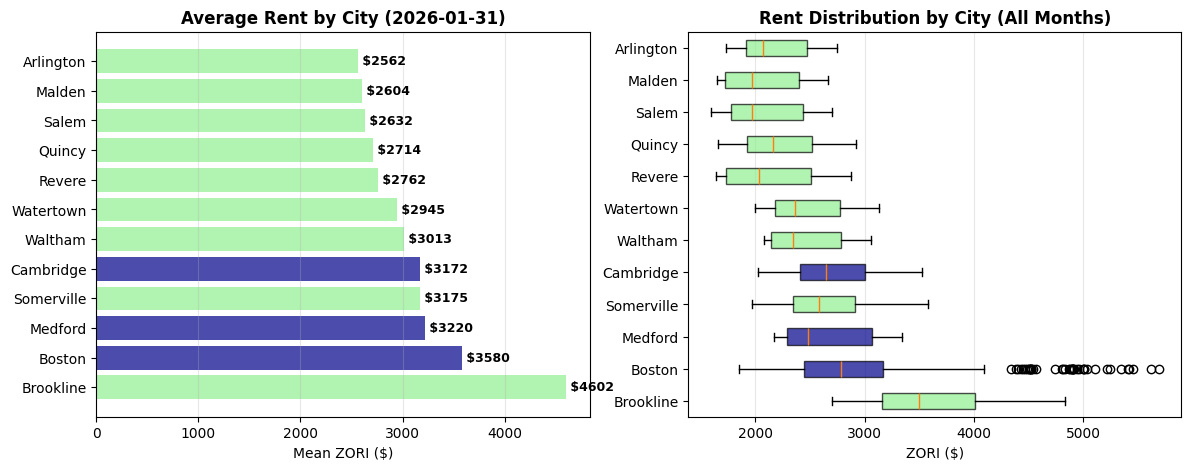

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

latest_date = zori_long['Date'].max()
latest_data = zori_long[zori_long['Date'] == latest_date]
    
city_stats = latest_data.groupby('City').agg({'ZORI': ['mean', 'min', 'max', 'count'],
'HasUniversity': 'sum'}).round(2)
city_stats.columns = ['Mean', 'Min', 'Max', 'Count', 'WithUniversity']
city_stats = city_stats.sort_values('Mean', ascending=False)
    

ax = axes[0]
colors = ['darkblue' if x > 0 else 'lightgreen' for x in city_stats['WithUniversity']]
ax.barh(range(len(city_stats)), city_stats['Mean'], color=colors, alpha=0.7)
ax.set_yticks(range(len(city_stats)))
ax.set_yticklabels(city_stats.index)
ax.set_xlabel('Mean ZORI ($)')
ax.set_title(f'Average Rent by City ({latest_date.date()})', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

for i, (idx, row) in enumerate(city_stats.iterrows()):
    ax.text(row['Mean'], i, f" ${row['Mean']:.0f}", va='center', fontweight='bold',fontsize=9)
    
# Distribution by city (box plot)
ax = axes[1]
city_order = city_stats.index.tolist()
city_data = [zori_long[zori_long['City'] == city]['ZORI'].dropna() for city in city_order]
bp = ax.boxplot(city_data, labels=city_order, vert=False, patch_artist=True)

for patch, city in zip(bp['boxes'], city_order):
    has_uni = city_stats.loc[city, 'WithUniversity'] > 0
    patch.set_facecolor('darkblue' if has_uni else 'lightgreen')
    patch.set_alpha(0.7)
    
ax.set_xlabel('ZORI ($)')
ax.set_title('Rent Distribution by City (All Months)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')


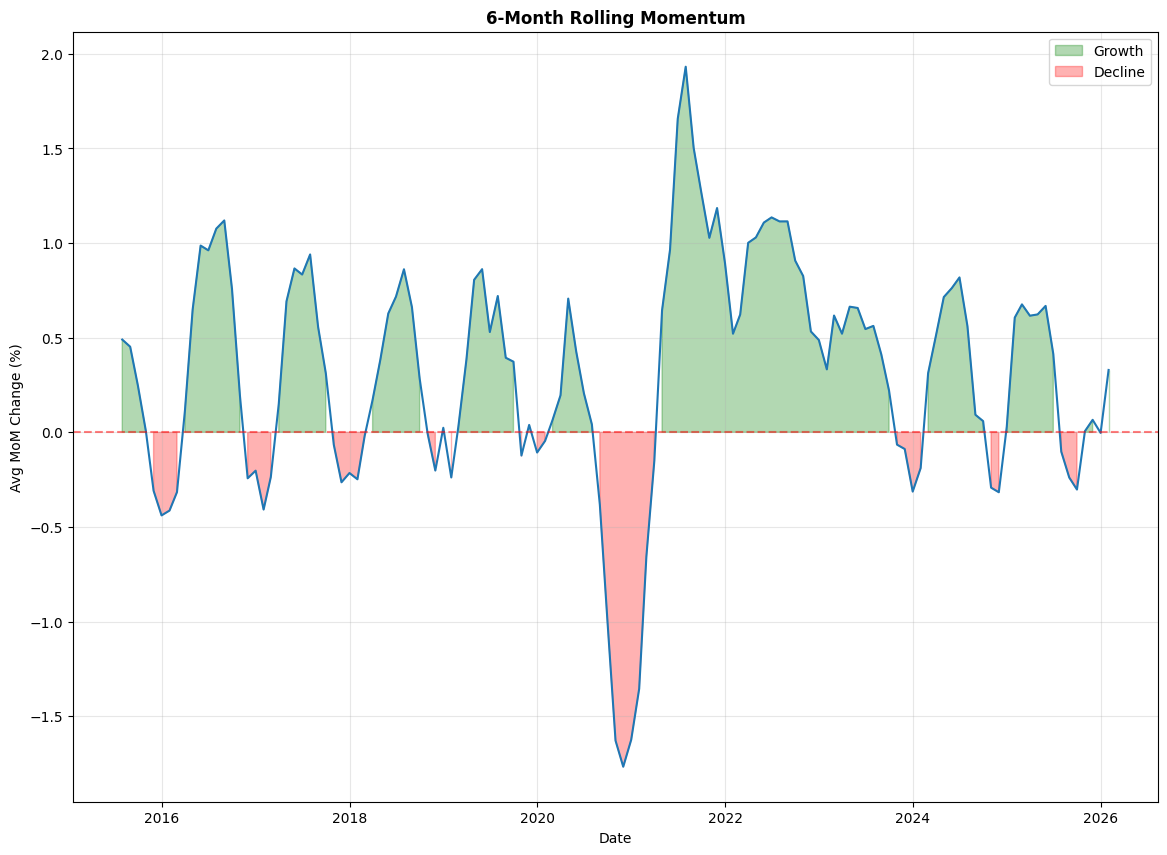

In [34]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1)

monthly_median = zori_long.groupby('Date')['ZORI'].median().sort_index()
mom_change = monthly_median.pct_change() * 100
mom_rolling = mom_change.rolling(window=6).mean()
ax.plot(mom_rolling.index, mom_rolling.values)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.fill_between(mom_rolling.index, 0, mom_rolling.values, 
                     where=(mom_rolling >= 0), alpha=0.3, color='green', label='Growth')
ax.fill_between(mom_rolling.index, 0, mom_rolling.values, 
                     where=(mom_rolling < 0), alpha=0.3, color='red', label='Decline')
    
ax.set_title('6-Month Rolling Momentum', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Avg MoM Change (%)')
ax.legend()
ax.grid(True, alpha=0.3)

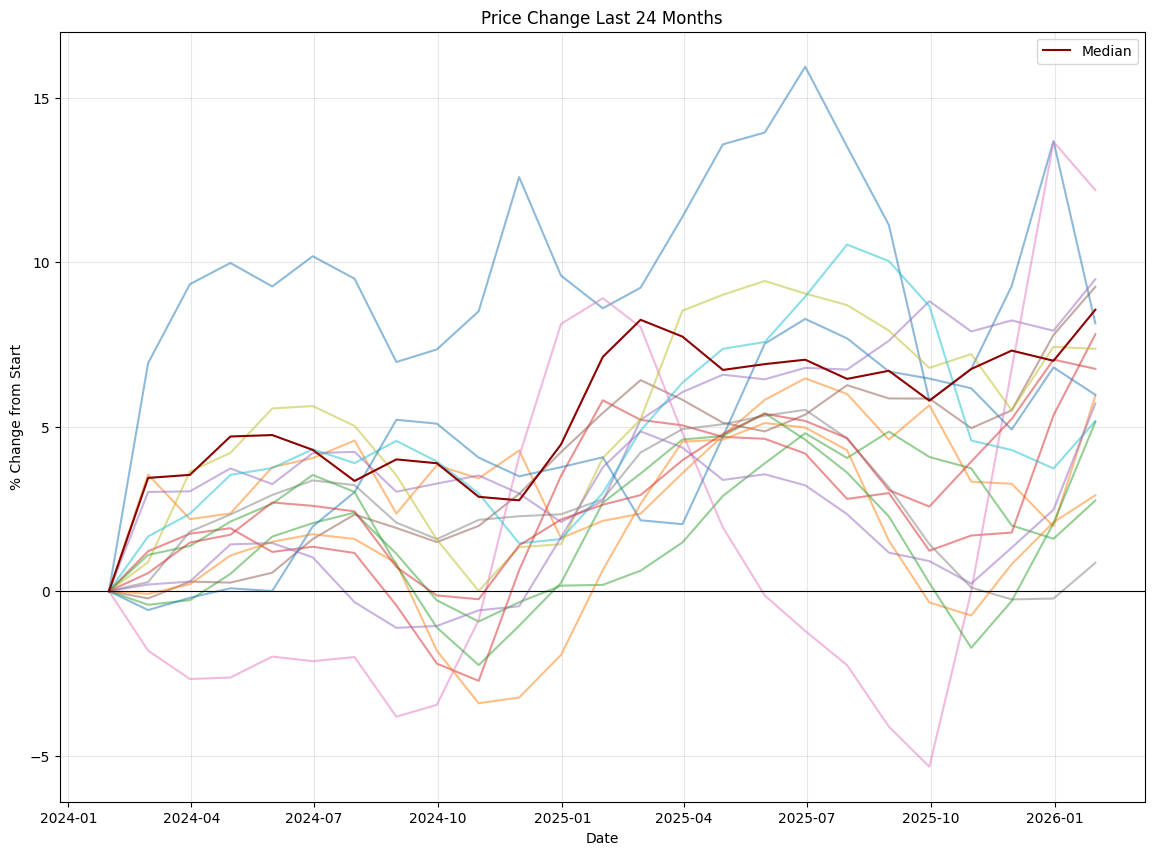

In [33]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1)
zori_long = zori_long[zori_long['City'] == 'Boston']
recent_months = 24
recent_date = zori_long['Date'].max() - pd.DateOffset(months=recent_months)
recent_data = zori_long[zori_long['Date'] >= recent_date]
for zip_code in recent_data['ZipCode'].unique():
    zip_recent = recent_data[recent_data['ZipCode'] == zip_code].sort_values('Date')
    normalized = (zip_recent['ZORI'] / zip_recent['ZORI'].iloc[0] - 1) * 100
    ax.plot(zip_recent['Date'], normalized, alpha=0.5, linewidth=1.5)
    
median_recent = recent_data.groupby('Date')['ZORI'].median().sort_index()
median_normalized = (median_recent / median_recent.iloc[0] - 1) * 100
ax.plot(median_normalized.index, median_normalized.values, color='darkred', label='Median')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.set_title(f'Price Change Last {recent_months} Months')
ax.set_xlabel('Date')
ax.set_ylabel('% Change from Start')
ax.legend()
ax.grid(True, alpha=0.3)

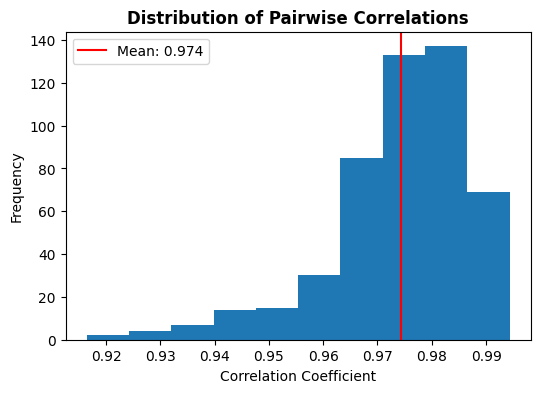

In [38]:
correlation_data = zori_long.pivot_table(index='Date', columns='ZipCode', values='ZORI')
corr_matrix = correlation_data.corr()
fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(1, 1, 1)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
corr_values = corr_matrix.where(mask).stack().values
ax.hist(corr_values)
ax.axvline(x=corr_values.mean(), color='red', label=f'Mean: {corr_values.mean():.3f}')
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Pairwise Correlations', fontweight='bold')
ax.legend()